In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 226M/226M [00:16<00:00, 14.0MB/s]

Extracting files...


Path to dataset files: C:\Users\Prasad\.cache\kagglehub\datasets\phucthaiv02\butterfly-image-classification\versions\3


In [1]:
train_dir  = r"C:\Users\Prasad\.cache\kagglehub\datasets\phucthaiv02\butterfly-image-classification\versions\3\train"
data_dir  = r"C:\Users\Prasad\.cache\kagglehub\datasets\phucthaiv02\butterfly-image-classification\versions\3"

In [2]:
data_dir

'C:\\Users\\Prasad\\.cache\\kagglehub\\datasets\\phucthaiv02\\butterfly-image-classification\\versions\\3'

In [3]:
import os

In [4]:
from PIL import Image

In [5]:
os.listdir(data_dir)

['test', 'Testing_set.csv', 'train', 'Training_set.csv']

In [6]:
def open_image(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

What is transfer learning, and why is it useful?


How does feature extraction differ from fine-tuning?

Why do we freeze the initial layers of a pre-trained model?

What is the advantage of using ResNet-50 over training a model from scratch?

How does GPU acceleration help in deep learning training?

What techniques can improve the accuracy of a transfer learning model?

Explain the role of CrossEntropyLoss in classification.

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Prasad\AppData\Local\Temp\ipykernel_20396\3109756351.py:1: SyntaxWarning: invalid escape sequence '\i'
  open_image(train_dir+'\image_1.jpg')


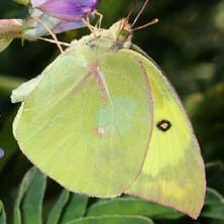

In [7]:
open_image(train_dir+'\image_1.jpg')

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Prasad\AppData\Local\Temp\ipykernel_20396\2945616320.py:1: SyntaxWarning: invalid escape sequence '\i'
  open_image(train_dir + '\image_2.jpg')


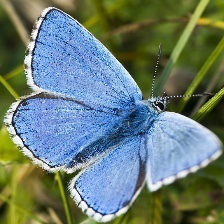

In [8]:
open_image(train_dir + '\image_2.jpg')

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
df_train = pd.read_csv(data_dir + '\\Training_set.csv')

In [11]:
df_train

,filename,label
0,Image_1.jpg,SOUTHERN DOGFACE
1,Image_2.jpg,ADONIS
2,Image_3.jpg,BROWN SIPROETA
3,Image_4.jpg,MONARCH
4,Image_5.jpg,GREEN CELLED CATTLEHEART
...,...,...
6494,Image_6495.jpg,MANGROVE SKIPPER
6495,Image_6496.jpg,MOURNING CLOAK
6496,Image_6497.jpg,APPOLLO
6497,Image_6498.jpg,ELBOWED PIERROT


In [21]:
df_train['label'].value_counts()

label
MOURNING CLOAK    131
SLEEPY ORANGE     107
ATALA             100
BROWN SIPROETA     99
CRECENT            97
                 ... 
AMERICAN SNOOT     74
GOLD BANDED        73
MALACHITE          73
CRIMSON PATCH      72
WOOD SATYR         71
Name: count, Length: 75, dtype: int64

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_train['label'] = le.fit_transform(df_train['label'])

In [28]:
import torch

df_train['label'] = torch.from_numpy(np.array(df_train['label'], dtype='float32'))

In [31]:
df_train['label']

0       66.0
1        0.0
2       12.0
3       44.0
4       33.0
        ... 
6494    40.0
6495    45.0
6496     4.0
6497    29.0
6498     5.0
Name: label, Length: 6499, dtype: float32

In [32]:
train_dir

'C:\\Users\\Prasad\\.cache\\kagglehub\\datasets\\phucthaiv02\\butterfly-image-classification\\versions\\3\\train'

In [36]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor



In [39]:
import os 
import stat

In [115]:
import shutil

src = r'C:\Users\Prasad\.cache\kagglehub\datasets\phucthaiv02\butterfly-image-classification\versions\3\train'
dst = r'D:\butterfly_data'

# Copy everything to a location where you have full control
shutil.copytree(src, dst)

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'D:\\butterfly_data'

In [138]:
import torchvision.transforms as T

img_size = 32*32

stats = ([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

In [139]:
def convert_image_to_tensor(path):
    for i in os.listdir(path):
        pt = '\\' + i
        img = open_image(path+pt)
        t = T.Compose([T.Resize(img_size), 
                                           T.Pad(8, padding_mode='reflect'),
                                           T.RandomCrop(img_size), 
                                           T.ToTensor(), 
                                           T.Normalize(*stats)])
        img = t(img)
    


In [140]:
train_ds = convert_image_to_tensor(dst)

In [143]:
train_ds

In [ ]:
from torch.utils.data import TensorDataset
train_ds = TensorDataset(train_ds, df_train['label'])